# Python 2DAlphabet ABCDEF Demo

Runs the pure-Python pass/fail fitter in `python/twodalphabet_py.py` on real
`mtt_vs_mt` coffea histograms stored in `outputs/2dalphabet_inputs/hists_{year}.pkl`
(produced by `make2dalphabet.ipynb`).

In [1]:
import pickle
import importlib
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#111111",
    "axes.facecolor": "#111111",
    "savefig.facecolor": "#111111",
    "axes.edgecolor": "#d1d5db",
    "axes.labelcolor": "#e5e7eb",
    "xtick.color": "#e5e7eb",
    "ytick.color": "#e5e7eb",
    "text.color": "#f9fafb",
    "grid.color": "#374151",
    "legend.facecolor": "#1f2937",
    "legend.edgecolor": "#4b5563",
})

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo / "python"))

import twodalphabet_py
twodalphabet_py = importlib.reload(twodalphabet_py)
from twodalphabet_py import Hist2D, PassFailModelInput, FormulaTransferFunction, PassFail2DFitter

year = "2024"
with open(repo / "outputs" / "2dalphabet_inputs" / f"hists_{year}.pkl", "rb") as f:
    hists = pickle.load(f)

## Build inputs

In [2]:
ANCAT = {"atcen": 0, "atfwd": 1, "2tcen": 2, "2tfwd": 3}

h_data  = hists["data"]
h_ttbar = hists["ttbar"]

inputs = PassFailModelInput(
    data_fail=Hist2D.from_hist(h_data[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]),
    data_pass=Hist2D.from_hist(h_data[{"anacat": ANCAT["2tcen"], "systematic": "nominal"}]),
    bkg_fail=Hist2D.from_hist(h_ttbar[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]),
    bkg_pass=Hist2D.from_hist(h_ttbar[{"anacat": ANCAT["2tcen"], "systematic": "nominal"}]),
)

# bin edges for plotting (from the fail slice; same grid for all)
h_ref    = h_data[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]
x_edges  = h_ref.axes[0].edges   # jet mass
y_edges  = h_ref.axes[1].edges   # m_tt

## Fit the ABCDEF 2DAlphabet Core Model

This uses the same core algebra as 2DAlphabet/Combine with the standard blinded ABCDEF layout. The pass signal window `D` is excluded from the likelihood, but the fitted model still predicts it. Coordinates `x` and `y` are bin centers mapped to `[0, 1]`, matching `TwoDAlphabet.alphawrap.ParametricFunction`.

## ABCDEF Region Map

The Python fitter now uses the same six-region sideband idea as the 2DAlphabet setup. The X axis is the top-candidate jet mass (`mt`/`jetmass`); the Y axis is `m_tt`.

```text
                       top-candidate mass axis (mt / jetmass)
                 25-105 GeV       105-210 GeV       210-475 GeV
              +---------------+----------------+----------------+
 FAIL / at    |       A       |       C        |       E        |
              | fail LOW      | fail SIG       | fail HIGH      |
              +---------------+----------------+----------------+
 PASS / 2t    |       B       |       D        |       F        |
              | pass LOW      | pass SIG       | pass HIGH      |
              +---------------+----------------+----------------+

D = blinded pass signal window in the background-only fit.
C remains included: qcd_D is predicted from qcd_C * Rpf(mt, mtt).
B and F constrain the pass/fail transfer function in sidebands.
A, C, and E anchor the free fail-region QCD bin parameters.
```

In code terms:

```text
qcd_fail[x, y] = free positive bin parameter
qcd_pass[x, y] = qcd_fail[x, y] * Rpf(x, y; theta)
fit bins = A + B + C + E + F
blinded prediction = D
```

In [3]:
sig_start, sig_end = 105.0, 210.0   # jet mass signal window [GeV]

tf = FormulaTransferFunction(
    "@0+@1*x+@2*y",
    {
        0: {"NOM": 1.5, "MIN": 0.0,  "MAX": 20.0, "ERROR": 0.2},
        1: {"NOM": 0.0, "MIN": -10.0, "MAX": 10.0, "ERROR": 0.2},
        2: {"NOM": 0.0, "MIN": -10.0, "MAX": 10.0, "ERROR": 0.2},
    },
)

fitter = PassFail2DFitter.abcdef(inputs, tf, sig_start=sig_start, sig_end=sig_end, blind_pass_signal=True)
fit = fitter.fit(options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8})

print("success:", fit.success)
print("message:", fit.message)
print("nll:    ", fit.nll)
print("params: ", fit.params)

success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
nll:     -41549.806540240264
params:  {'rpf_par0': 0.6663799275287853, 'rpf_par1': -0.1852462052179125, 'rpf_par2': 0.803193026002224}


## Transfer Function

The fitted transfer function is the pass/fail QCD ratio,
`Rpf(mt, mtt) = qcd_pass / qcd_fail`, evaluated at the normalized bin centers
used by the 2DAlphabet-style formula.


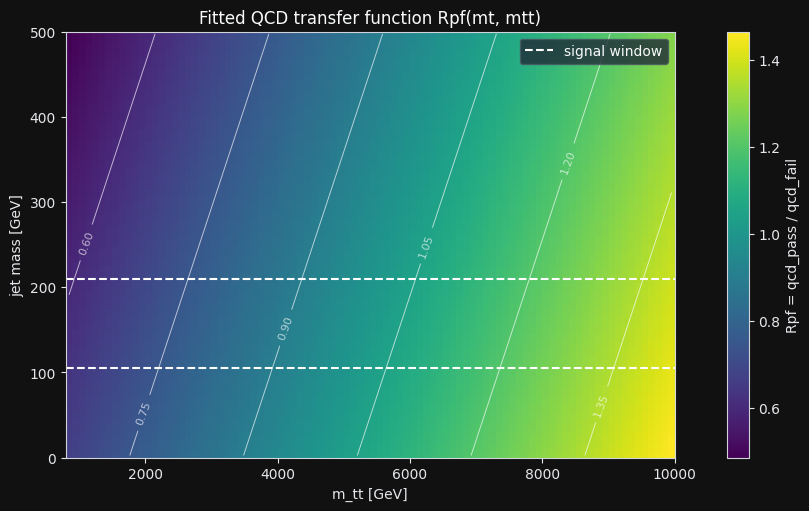

Rpf range: 0.4864251328261049 to 1.4642815430157772


In [4]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

rpf = fit.rpf
jetmass_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
mtt_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
mtt_grid, jetmass_grid = np.meshgrid(mtt_centers, jetmass_centers)

mesh = ax.pcolormesh(
    y_edges,
    x_edges,
    rpf,
    shading="auto",
    cmap="viridis",
)

contours = ax.contour(
    mtt_grid,
    jetmass_grid,
    rpf,
    colors="white",
    linewidths=0.7,
    alpha=0.65,
)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")

ax.axhline(sig_start, color="white", linewidth=1.5, linestyle="--", label="signal window")
ax.axhline(sig_end, color="white", linewidth=1.5, linestyle="--")
ax.set_title("Fitted QCD transfer function Rpf(mt, mtt)")
ax.set_xlabel("m_tt [GeV]")
ax.set_ylabel("jet mass [GeV]")
ax.legend(loc="upper right")
fig.colorbar(mesh, ax=ax, label="Rpf = qcd_pass / qcd_fail")
plt.show()

print("Rpf range:", np.nanmin(rpf), "to", np.nanmax(rpf))


In [5]:
print("ABCDEF yields:")
for source, yields in fit.abcdef_yields.items():
    print(f"  {source}:", ", ".join(f"{r}={v:.1f}" for r, v in yields.items()))

ABCDEF yields:
  data: A=7301.0, B=6556.0, C=3316.0, D=7726.0, E=937.0, F=1465.0
  qcd: A=6964.0, B=4975.7, C=2093.5, D=1412.3, E=708.7, F=461.8
  expected: A=7289.0, B=6680.7, C=3352.0, D=11336.1, E=946.2, F=1770.1


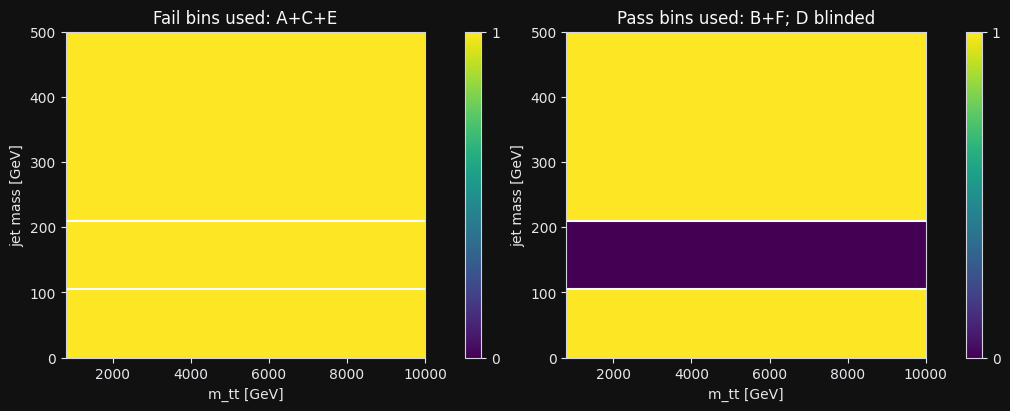

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, mask, title in [
    (axes[0], fit.fail_fit_mask, "Fail bins used: A+C+E"),
    (axes[1], fit.pass_fit_mask, "Pass bins used: B+F; D blinded"),
]:
    mesh = ax.pcolormesh(y_edges, x_edges, mask.astype(int), shading="auto", vmin=0, vmax=1)
    ax.axhline(sig_start, color="white", linewidth=1.5)
    ax.axhline(sig_end,   color="white", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax, ticks=[0, 1])
plt.show()

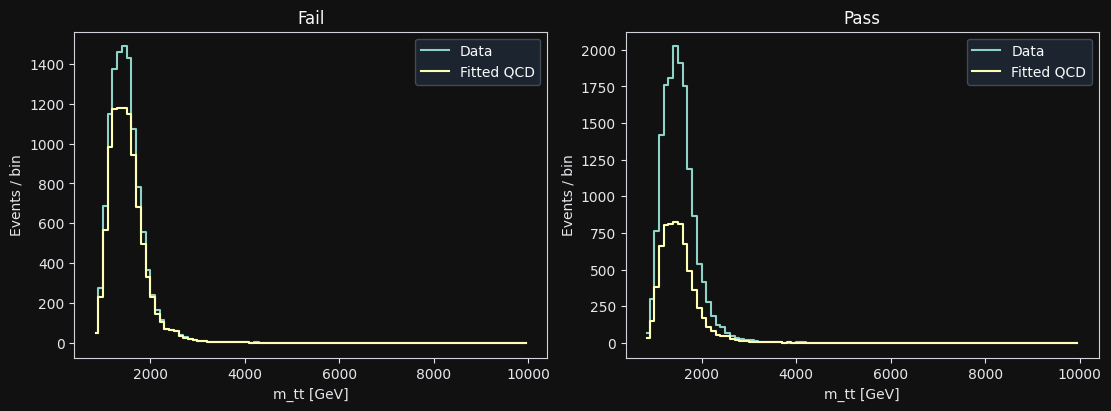

In [7]:
mtt_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

fig, (ax_fail, ax_pass) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, data_2d, qcd_2d, title in [
    (ax_fail, inputs.data_fail.values, fit.qcd_fail, "Fail"),
    (ax_pass, inputs.data_pass.values, fit.qcd_pass, "Pass"),
]:
    ax.step(mtt_centers, data_2d.sum(axis=0), where="mid", label="Data")
    ax.step(mtt_centers, qcd_2d.sum(axis=0),  where="mid", label="Fitted QCD")
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("Events / bin")
    ax.set_title(title)
    ax.legend()
plt.show()

## Diagnostic closure checks

These checks are meant to answer a physics question before a machinery
question: is the problem coming from the fitted QCD transfer factor or from a
fixed non-QCD component?

For the current 2024 inputs, the blinded D disagreement is dominated by the
fixed `ttbar` template. The QCD prediction in D is small compared with the
fixed `ttbar` contribution, while the fitted fail/control regions close at the
few-percent level.

In [8]:
regions = fitter.regions
bkg_yields = regions.yields(inputs.bkg_fail.values, inputs.bkg_pass.values)

print("ABCDEF yields (events):")
print("source       " + " ".join(f"{r:>10}" for r in "ABCDEF") + f" {'total':>10}")
for source, yields in [
    ("data", fit.abcdef_yields["data"]),
    ("qcd", fit.abcdef_yields["qcd"]),
    ("ttbar", bkg_yields),
    ("expected", fit.abcdef_yields["expected"]),
]:
    total = sum(yields[r] for r in "ABCDEF")
    print(f"{source:<10} " + " ".join(f"{yields[r]:10.1f}" for r in "ABCDEF") + f" {total:10.1f}")

fit_regions = ["A", "B", "C", "E", "F"]
data_fit = sum(fit.abcdef_yields["data"][r] for r in fit_regions)
exp_fit = sum(fit.abcdef_yields["expected"][r] for r in fit_regions)
data_d = fit.abcdef_yields["data"]["D"]
exp_d = fit.abcdef_yields["expected"]["D"]
print("\nClosure in fitted bins (A+B+C+E+F):")
print(f"  data={data_fit:.1f}, expected={exp_fit:.1f}, data/expected={data_fit / exp_fit:.3f}")
print("\nClosure in blinded D:")
print(f"  data={data_d:.1f}, expected={exp_d:.1f}, data/expected={data_d / exp_d:.3f}")
print(
    "  D components: "
    f"QCD={fit.abcdef_yields['qcd']['D']:.1f}, "
    f"ttbar={bkg_yields['D']:.1f}, "
    f"ttbar/data={bkg_yields['D'] / data_d:.3f}"
)

for name, data_2d, exp_2d in [
    ("fail", inputs.data_fail.values, fit.expected_fail),
    ("pass", inputs.data_pass.values, fit.expected_pass),
]:
    print(f"\nNegative total expected bins ({name}): {(exp_2d < 0).sum()} / {exp_2d.size}")
    qcd_sub = data_2d - (inputs.bkg_fail.values if name == "fail" else inputs.bkg_pass.values)
    print(f"Negative data-ttbar bins ({name}): {(qcd_sub < 0).sum()} / {qcd_sub.size}; min={qcd_sub.min():.2f}")

ABCDEF yields (events):
source                A          B          C          D          E          F      total
data           7301.0     6556.0     3316.0     7726.0      937.0     1465.0    27301.0
qcd            6964.0     4975.7     2093.5     1412.3      708.7      461.8    16616.0
ttbar           325.0     1705.0     1258.4     9923.8      237.5     1308.3    14758.0
expected       7289.0     6680.7     3352.0    11336.1      946.2     1770.1    31374.0

Closure in fitted bins (A+B+C+E+F):
  data=19575.0, expected=20037.9, data/expected=0.977

Closure in blinded D:
  data=7726.0, expected=11336.1, data/expected=0.682
  D components: QCD=1412.3, ttbar=9923.8, ttbar/data=1.284

Negative total expected bins (fail): 26 / 9200
Negative data-ttbar bins (fail): 328 / 9200; min=-5.00

Negative total expected bins (pass): 51 / 9200
Negative data-ttbar bins (pass): 934 / 9200; min=-114.22


In [9]:
mtt_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
sig_rows = np.where(regions.sig[:, 0])[0]
side_rows = np.r_[np.where(regions.low[:, 0])[0], np.where(regions.high[:, 0])[0]]

proj = {
    "data_D": inputs.data_pass.values[sig_rows, :].sum(axis=0),
    "qcd_D": fit.qcd_pass[sig_rows, :].sum(axis=0),
    "ttbar_D": inputs.bkg_pass.values[sig_rows, :].sum(axis=0),
    "exp_D": fit.expected_pass[sig_rows, :].sum(axis=0),
    "data_BF": inputs.data_pass.values[side_rows, :].sum(axis=0),
    "exp_BF": fit.expected_pass[side_rows, :].sum(axis=0),
    "data_C": inputs.data_fail.values[sig_rows, :].sum(axis=0),
    "exp_C": fit.expected_fail[sig_rows, :].sum(axis=0),
}

print("D m_tt bins with |data-expected|/sqrt(expected) > 2:")
for mtt, data, exp, qcd, ttbar in zip(
    mtt_centers, proj["data_D"], proj["exp_D"], proj["qcd_D"], proj["ttbar_D"]
):
    pull = (data - exp) / np.sqrt(exp) if exp > 0 else np.nan
    if exp > 10 and abs(pull) > 2:
        print(
            f"  mtt={mtt:7.0f}: data={data:7.1f}, exp={exp:7.1f}, "
            f"qcd={qcd:6.1f}, ttbar={ttbar:7.1f}, pull={pull:6.2f}"
        )

D m_tt bins with |data-expected|/sqrt(expected) > 2:
  mtt=    850: data=   18.0, exp=   33.0, qcd=   2.3, ttbar=   30.7, pull= -2.61
  mtt=    950: data=  107.0, exp=  220.1, qcd=  18.1, ttbar=  202.0, pull= -7.62
  mtt=   1050: data=  324.0, exp=  595.9, qcd=  67.2, ttbar=  528.7, pull=-11.14
  mtt=   1150: data=  635.0, exp= 1018.2, qcd= 121.9, ttbar=  896.2, pull=-12.01
  mtt=   1250: data=  824.0, exp= 1334.0, qcd= 171.0, ttbar= 1163.0, pull=-13.96
  mtt=   1350: data=  866.0, exp= 1573.8, qcd= 161.3, ttbar= 1412.5, pull=-17.84
  mtt=   1450: data= 1006.0, exp= 1871.6, qcd= 156.7, ttbar= 1714.9, pull=-20.01
  mtt=   1550: data= 1011.0, exp= 1577.1, qcd= 172.6, ttbar= 1404.5, pull=-14.25
  mtt=   1650: data=  929.0, exp= 1048.8, qcd= 151.8, ttbar=  897.0, pull= -3.70
  mtt=   1950: data=  261.0, exp=  305.0, qcd=  57.3, ttbar=  247.8, pull= -2.52


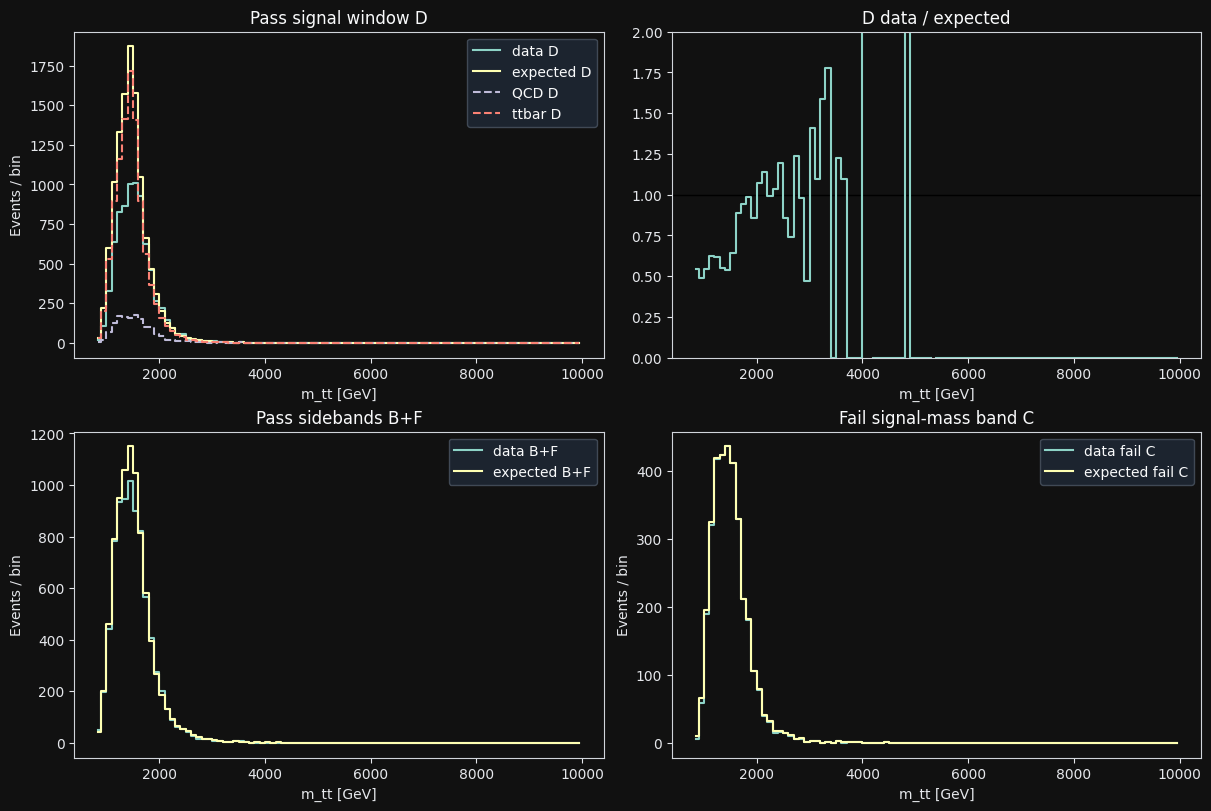

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.step(mtt_centers, proj["data_D"], where="mid", label="data D")
ax.step(mtt_centers, proj["exp_D"], where="mid", label="expected D")
ax.step(mtt_centers, proj["qcd_D"], where="mid", linestyle="--", label="QCD D")
ax.step(mtt_centers, proj["ttbar_D"], where="mid", linestyle="--", label="ttbar D")
ax.set_title("Pass signal window D")
ax.set_xlabel("m_tt [GeV]")
ax.set_ylabel("Events / bin")
ax.legend()

ax = axes[0, 1]
ratio = np.divide(
    proj["data_D"],
    proj["exp_D"],
    out=np.full_like(proj["data_D"], np.nan),
    where=proj["exp_D"] > 0,
)
ax.axhline(1.0, color="black", linewidth=1)
ax.step(mtt_centers, ratio, where="mid")
ax.set_ylim(0, 2)
ax.set_title("D data / expected")
ax.set_xlabel("m_tt [GeV]")

ax = axes[1, 0]
ax.step(mtt_centers, proj["data_BF"], where="mid", label="data B+F")
ax.step(mtt_centers, proj["exp_BF"], where="mid", label="expected B+F")
ax.set_title("Pass sidebands B+F")
ax.set_xlabel("m_tt [GeV]")
ax.set_ylabel("Events / bin")
ax.legend()

ax = axes[1, 1]
ax.step(mtt_centers, proj["data_C"], where="mid", label="data fail C")
ax.step(mtt_centers, proj["exp_C"], where="mid", label="expected fail C")
ax.set_title("Fail signal-mass band C")
ax.set_xlabel("m_tt [GeV]")
ax.set_ylabel("Events / bin")
ax.legend()
plt.show()

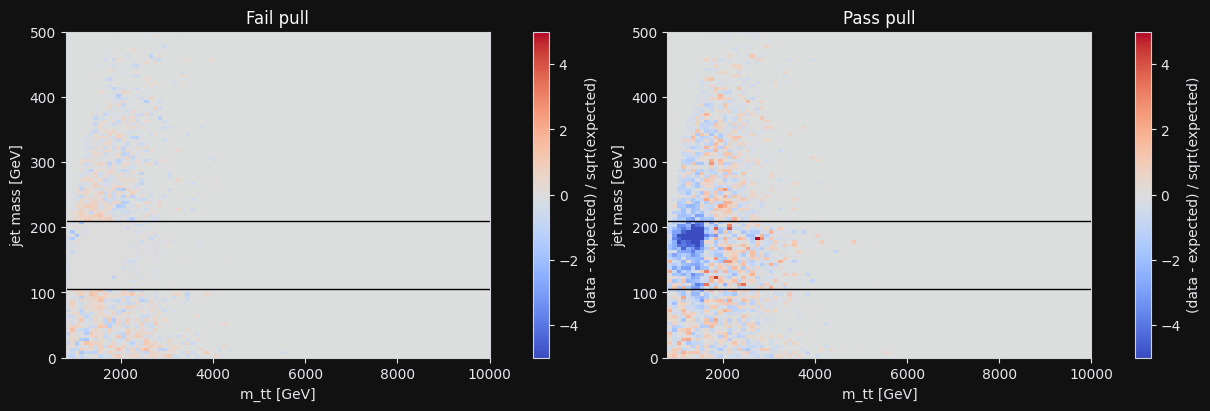

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, data_2d, exp_2d, title in [
    (axes[0], inputs.data_fail.values, fit.expected_fail, "Fail pull"),
    (axes[1], inputs.data_pass.values, fit.expected_pass, "Pass pull"),
]:
    pull = (data_2d - exp_2d) / np.sqrt(np.maximum(exp_2d, 1.0))
    mesh = ax.pcolormesh(
        y_edges,
        x_edges,
        np.clip(pull, -5, 5),
        shading="auto",
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
    )
    ax.axhline(sig_start, color="black", linewidth=1)
    ax.axhline(sig_end, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax, label="(data - expected) / sqrt(expected)")
plt.show()